# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
from sklearn.metrics import classification_report, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

### Explore Target Feature 

C:\Users\pc\AppData\Local\Temp\ipykernel_18168\4285989075.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='Recommended IND', palette='Set1')


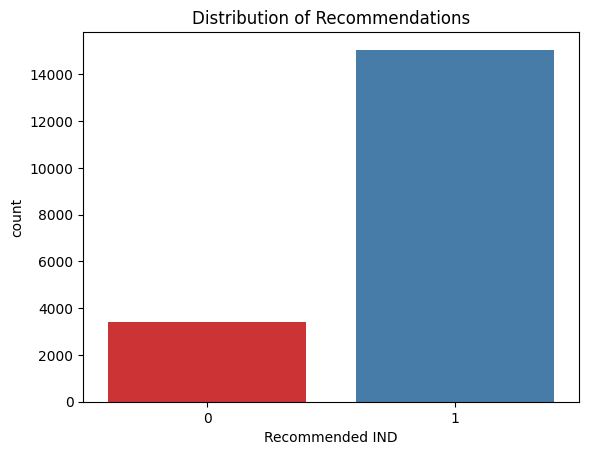

Recommended IND distribution(%): 
1: 81.6%   |   0: 18.4%


In [4]:
sns.countplot(df, x='Recommended IND', palette='Set1')

plt.title('Distribution of Recommendations')

vals = (df['Recommended IND'].value_counts(normalize=True).values)

plt.show()

print(f'Recommended IND distribution(%): \n1: {(vals[0]*100):.1f}%   |   0: {(vals[1]*100):.1f}%')

#### Age distribution grouped by Recommendation

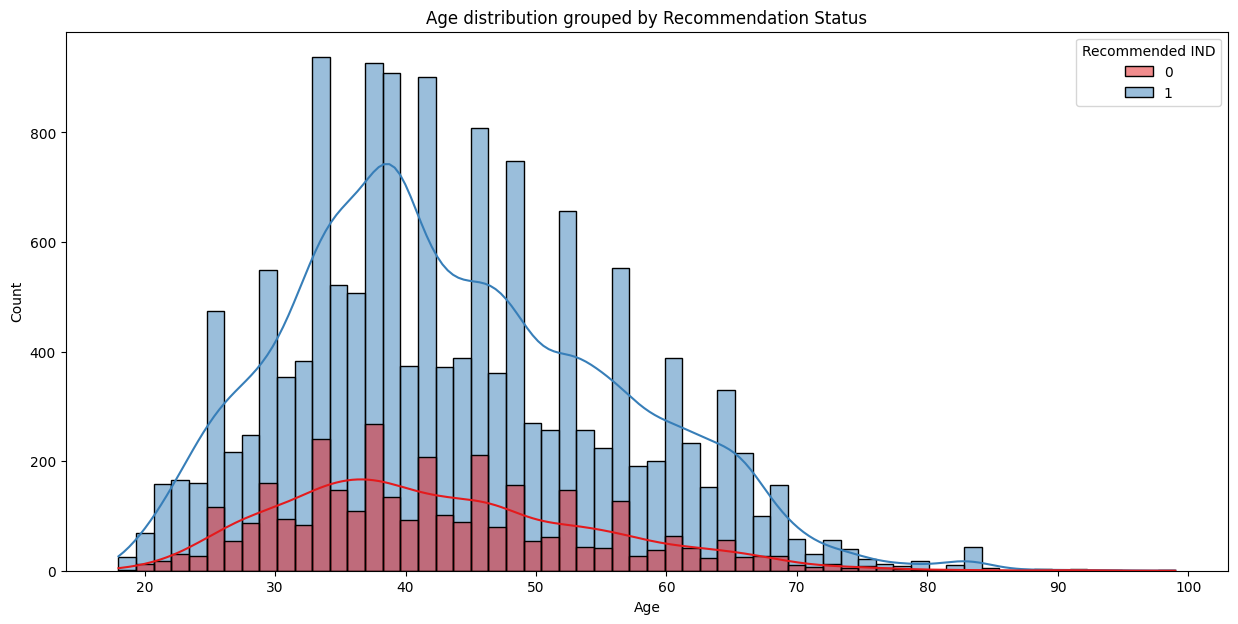

In [5]:
# Age distribution grouped by Recommendation
plt.figure(figsize=(15,7))
sns.histplot(df, x='Age', hue='Recommended IND', kde= True, palette='Set1')
plt.title('Age distribution grouped by Recommendation Status')
plt.show()

#### Department and Class Name distribution grouped by Recommendation


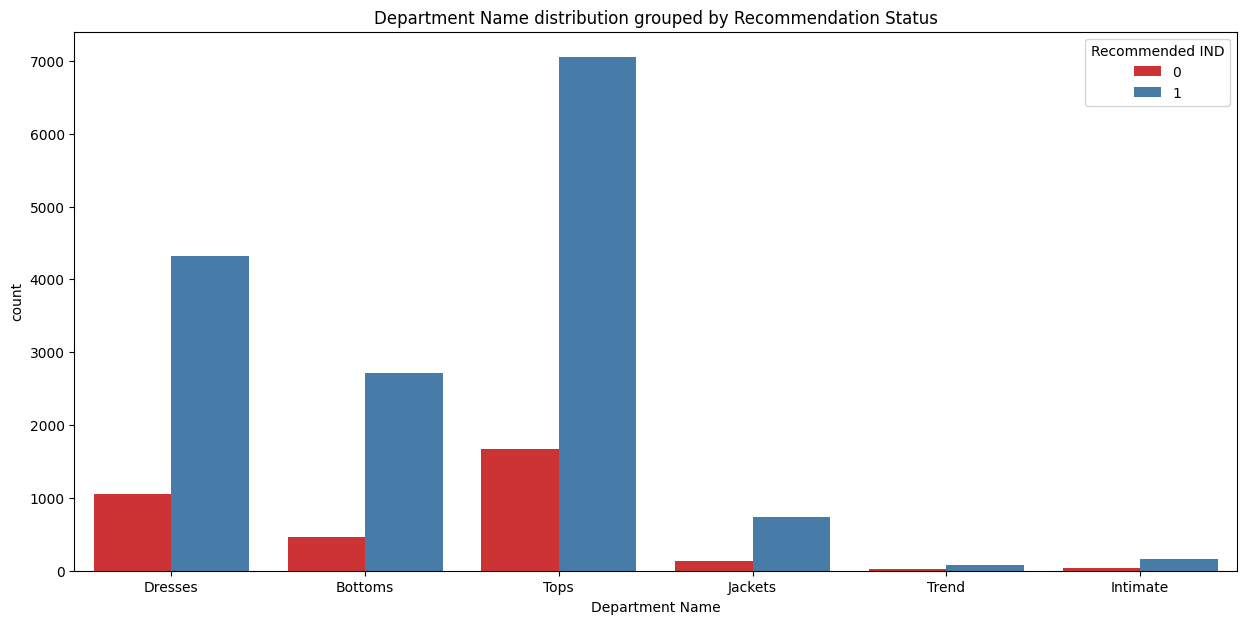

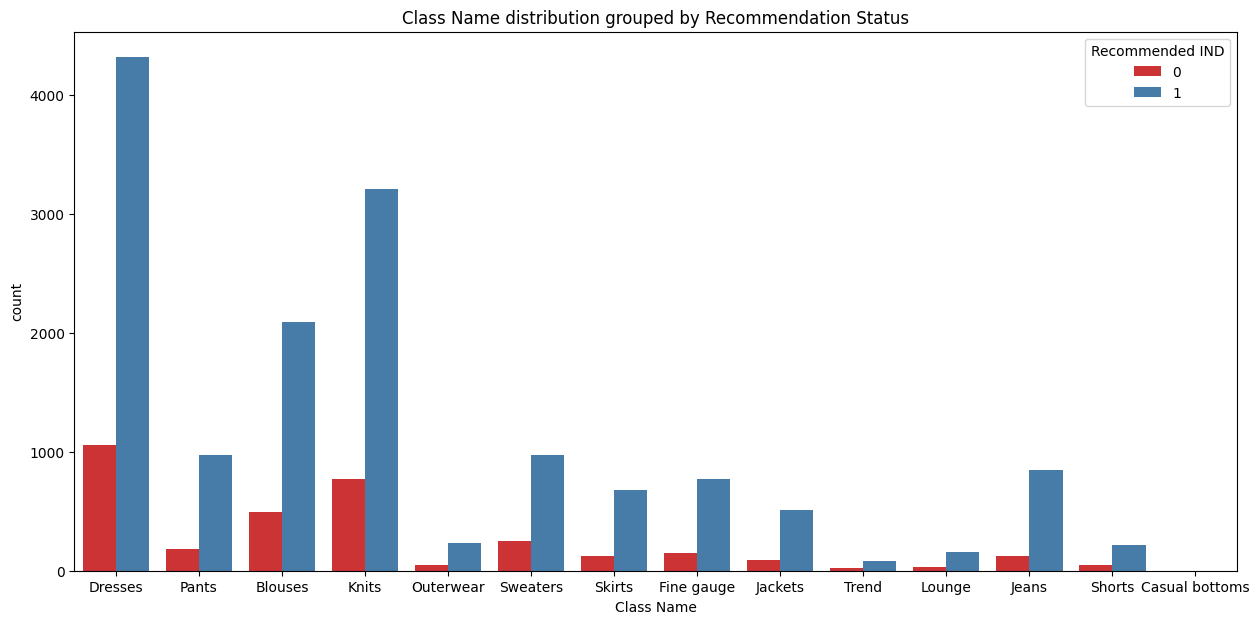

In [6]:
plt.figure(figsize=(15,7))
sns.countplot(df, x='Department Name', hue='Recommended IND', palette='Set1')
plt.title('Department Name distribution grouped by Recommendation Status')
plt.show()

plt.figure(figsize=(15,7))
sns.countplot(data=df, x='Class Name', hue='Recommended IND', orient='v', palette='Set1')
plt.title('Class Name distribution grouped by Recommendation Status')
plt.show()


### Explore Text Features

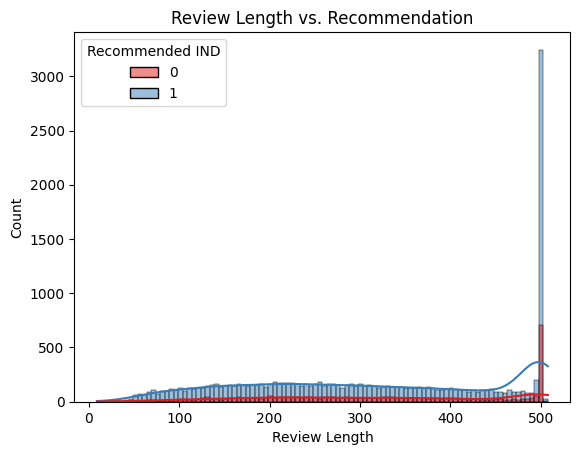

In [7]:
# Create a temporary column for review length
df['Review Length'] = df['Review Text'].astype(str).apply(len)

# Plot the distribution of review lengths
sns.histplot(data=df, x='Review Length', hue='Recommended IND', bins=100, kde=True, palette='Set1')
plt.title('Review Length vs. Recommendation')
plt.show()

The review length seems to be limited to 500 character


## Building Pipeline

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin

class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    def __init__(self):
        
        self.nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        # use nlp.pipe for highly optimized batch processing
        processed_docs = []
        for doc in self.nlp.pipe(X.astype(str).str.lower(), batch_size=500):
            tokens = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]
            # Join back into a string
            processed_docs.append(" ".join(tokens)) 
            
        return processed_docs

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin


class TextLengthExtractor(BaseEstimator, TransformerMixin):
    """
    Custom Scikit-Learn Transformer to extract the length of text.
    """
    def fit(self, X, y=None):
        # The fit method is required but doesn't need to do anything for this extractor
        return self
    
    def transform(self, X):
        # X is expected to be a pandas Series of text (like df['Review Text'])
        # We calculate the length of each string and return it as a 2D array
        
        # Fill missing values with empty strings just in case
        X_filled = X.fillna("") 
        
        # Calculate lengths and reshape to a 2D column array, which scikit-learn expects
        lengths = X_filled.apply(len).values.reshape(-1, 1)
        
        return lengths

In [10]:
# Define feature groups
# Note: 'Clothing ID' is an integer, but it represents a category
numeric_features = ['Age', 'Positive Feedback Count']
categorical_features = ['Clothing ID', 'Division Name', 'Department Name', 'Class Name']

review_text_feature = 'Review Text' # Passed as a string (not a list) so TfidfVectorizer gets a 1D array
review_title_feature = 'Title'

# The individual pipelines for numerical and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a pipeline for the Review Text
review_text_transformer = Pipeline(steps=[
    ('lemmatizer', SpacyLemmatizer()),
    ('tfidf', TfidfVectorizer(max_features=1000)) # Vectorizer handles the final token split
])

# Create a pipeline for the Title
title_text_transformer = Pipeline(steps=[
    ('lemmatizer', SpacyLemmatizer()),
    ('tfidf', TfidfVectorizer(max_features=200))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),

        ('review_text_pipe', review_text_transformer, review_text_feature),
        ('review_title_pipe', title_text_transformer, review_title_feature),

        ('review_text_len', TextLengthExtractor(), review_text_feature)
    ])

# the master pipeline 
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=2))
])

## Training Pipeline

In [11]:
# Fit the pipeline to the training data
pipeline.fit(X_train.copy(), y_train.copy())

# Make predictions on the test set
y_pred = pipeline.predict(X_test.copy())

# Quick initial evaluation
print("Base Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nBase Model Classification Report:\n", classification_report(y_test, y_pred))

Base Model Accuracy: 0.8536585365853658

Base Model Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.24      0.36       327
           1       0.86      0.99      0.92      1518

    accuracy                           0.85      1845
   macro avg       0.83      0.61      0.64      1845
weighted avg       0.85      0.85      0.82      1845



## Fine-Tuning Pipeline

In [12]:
param_distributions = {
    # preprocessor -> review_text_pipe -> tfidf -> max_features
    'preprocessor__review_text_pipe__tfidf__max_features': [500, 1000], 
    
    # preprocessor -> review_title_pipe -> tfidf -> max_features
    'preprocessor__review_title_pipe__tfidf__max_features': [100, 200],
    
    'classifier__max_depth': [10, 20, None],
    'classifier__n_estimators': [50, 100]
}

# Initialize RandomizedSearchCV
# n_iter=5 means it will randomly pick and test only 5 combinations
random_search = RandomizedSearchCV(
    pipeline, 
    param_distributions=param_distributions, 
    n_iter=5,  
    cv=3, 
    n_jobs=-1, 
    verbose=3, 
    scoring='f1_macro',
    random_state=42 
)

# Run the search
random_search.fit(X_train, y_train)

# Extract the best model and evaluate it
print("Best Parameters found:", random_search.best_params_)

best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nOptimized Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nOptimized Model Classification Report:\n", classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters found: {'preprocessor__review_title_pipe__tfidf__max_features': 200, 'preprocessor__review_text_pipe__tfidf__max_features': 1000, 'classifier__n_estimators': 50, 'classifier__max_depth': 20}

Optimized Model Accuracy: 0.8634146341463415

Optimized Model Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.60      0.61       327
           1       0.91      0.92      0.92      1518

    accuracy                           0.86      1845
   macro avg       0.77      0.76      0.76      1845
weighted avg       0.86      0.86      0.86      1845



In [ ]:
import joblib

base_model_filename = r'models\base_rf_pipeline.pkl'
tuned_model_filename = r'models\tuned_rf_pipeline.pkl'

joblib.dump(pipeline, base_model_filename)

joblib.dump(best_model, tuned_model_filename)

print(f"Success! Models saved as:\n- {base_model_filename}\n- {tuned_model_filename}")

Success! Models saved as:
- models\base_rf_pipeline.pkl
- models\tuned_rf_pipeline.pkl
